# EDA (Exploratory Data Analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

/home/lucazini03/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### 1. Load datsets and inspect shapes and first few rows
Start by loading the training and test datasets, and check their shapes to understand the number of samples and features.

Kaggle provided the following datasets:

- `train.csv`: Contains the training data with features and target variable.
- `test.csv`: Contains the test data with features but without the target variable. This is what we will test our model on, to get our position in the leaderboard.
- `sample_submission.csv`: Contains the format for the submission file.

Choose whether to run the code in local or in Kaggle or in Colab.

In [2]:
local = True
kaggle = False
colab = False

In [3]:
if local:
    train = pd.read_csv("train.csv",)
    test = pd.read_csv("test.csv")
    submission = pd.read_csv("sample_submission.csv")
elif kaggle:
    train = pd.read_csv("/kaggle/input/competitions/playground-series-s5e8/train.csv")
    test = pd.read_csv("/kaggle/input/competitions/playground-series-s5e8/test.csv")
    submission = pd.read_csv("/kaggle/input/competitions/playground-series-s5e8/sample_submission.csv")
elif colab:
    from google.colab import drive
    drive.mount('/content/drive')
    train = pd.read_csv("/content/drive/MyDrive/machine learning/train.csv")
    test = pd.read_csv("/content/drive/MyDrive/machine learning/test.csv")
    submission = pd.read_csv("/content/drive/MyDrive/machine learning/sample_submission.csv")

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", submission.shape)

Train shape: (750000, 18)
Test shape: (250000, 17)
Submission shape: (250000, 2)


The shape of the train, test, and submission datasets is as follows:
- Train shape: (750k, 18)
- Test shape: (250k, 17): the test set has one less column than the train set (the target variable column). That is the way competitions are usually structured, to prevent data leakage and ensure that the model is evaluated on unseen data.
- Submission shape: (250k, 2): those two columns are usually the ID column and the target variable column, where I will fill in my predictions for the test set.

In [5]:
train.head(10)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
5,5,24,admin.,single,secondary,no,1882,yes,no,cellular,20,apr,1010,3,-1,0,unknown,0
6,6,39,blue-collar,married,secondary,no,0,no,no,telephone,21,nov,90,1,-1,0,unknown,0
7,7,50,admin.,single,secondary,no,1595,no,no,telephone,31,jul,49,25,-1,0,unknown,0
8,8,46,blue-collar,married,primary,no,1463,no,no,cellular,4,aug,50,1,-1,0,unknown,0
9,9,39,management,divorced,tertiary,no,25,yes,no,cellular,8,may,119,1,-1,0,unknown,0


### 2. Check missing values

In [6]:
# missing values
if train.isnull().sum().sum() == 0 and test.isnull().sum().sum() == 0:
    print("No missing values in train and test datasets.")

No missing values in train and test datasets.


### 3. Data Exploration
Check data types, unique values and meaning, along with correlations between features and with the target variable. 

In [7]:
for column in train.columns:
    print(f"Unique values in {column}: {train[column].unique()}")
    print('-------------------------------------')

Unique values in id: [     0      1      2 ... 749997 749998 749999]
-------------------------------------
Unique values in age: [42 38 36 27 26 24 39 50 46 32 37 57 33 47 35 49 77 40 54 56 51 30 67 58
 59 45 43 29 48 31 28 34 60 52 41 81 23 62 53 72 55 25 44 61 63 69 75 71
 64 22 83 70 80 21 65 74 68 19 73 66 79 20 84 86 76 18 82 78 87 85 88 94
 93 89 92 95 90 91]
-------------------------------------
Unique values in job: ['technician' 'blue-collar' 'student' 'admin.' 'management' 'entrepreneur'
 'self-employed' 'unknown' 'services' 'retired' 'housemaid' 'unemployed']
-------------------------------------
Unique values in marital: ['married' 'single' 'divorced']
-------------------------------------
Unique values in education: ['secondary' 'primary' 'tertiary' 'unknown']
-------------------------------------
Unique values in default: ['no' 'yes']
-------------------------------------
Unique values in balance: [    7   514   602 ... 13023  4003  8218]
---------------------------------

**Bank client data**
- Age (numeric)
- Job (categorical): job descriptions
- Marital (categorical): marital status
- Education (categorical): education level
- Default (categorical): has credit card?
- Balance (numeric): average yearly balance in euros
- Housing (categorical): has housing loan?
- Loan (categorical): has personal loan?

**Related with the last contact of the current campaign**

A campaign is a planned marketing effort over a period of time, aimed at a group of clients.
Here, it’s a phone-based campaign: the bank calls clients to ask if they want to subscribe to a term deposit. A contact is one attempt to reach a client during a campaign. The last contact is the most recent attempt to reach the client during the current campaign, and its attributes can provide insights into the client's behavior and preferences.

- Contact (categorical): contact communication type
- Day (numeric): last contact day of the month
- Month (categorical): last contact month of the year
- Duration (numeric): last contact duration, in seconds

**Other attributes**

P stands for previous, and it refers to the previous campaign. The attributes related to the previous campaign can provide insights into the client's past interactions with the bank and their likelihood of subscribing to a term deposit.

- Campaign (numeric): number of contacts performed during this campaign and for this client (includes last contact)
- Pdays (numeric): number of days that passed by after the client was last contacted from a previous campaign. If the value is -1, it means the client was not previously contacted.
- Previous (numeric): number of contacts performed before this campaign and for this client
- Poutcome (categorical): outcome of the previous marketing campaign

**Target variable**
- Y (categorical): has the client subscribed a term deposit? (binary: "yes or "no")

In [8]:
# id is not a useful feature for our model, so we drop it from both datasets

train.drop("id", axis=1, inplace=True)
test.drop("id", axis=1, inplace=True)

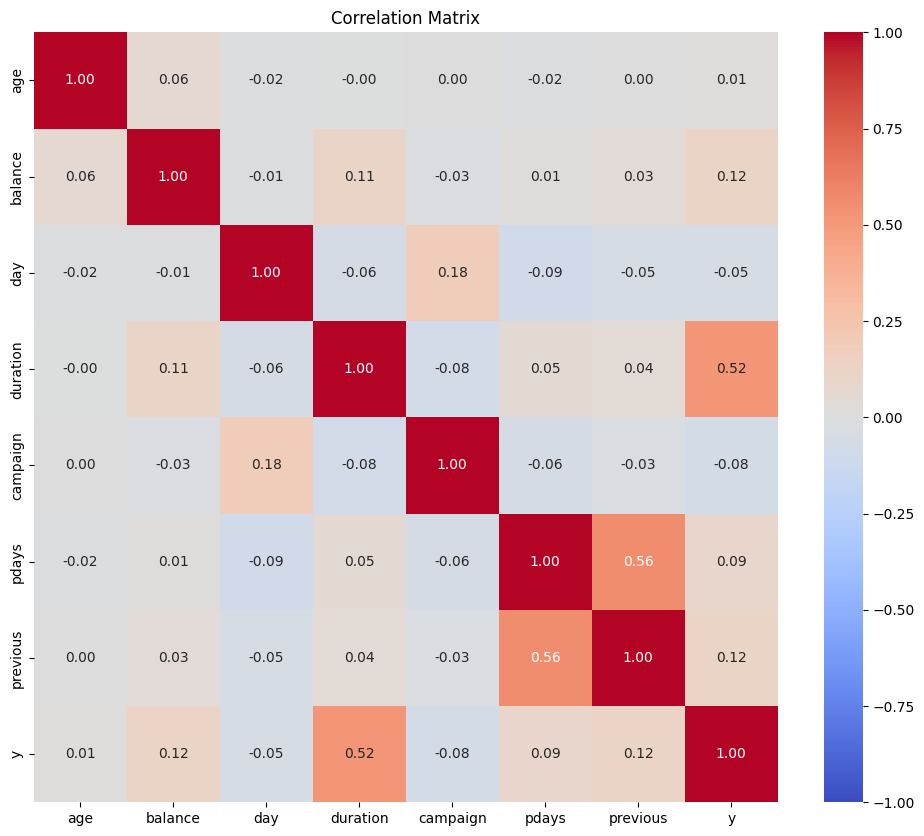

In [9]:
# let's check the correlation between the features and the target variable
numerical_features = [col for col in train.select_dtypes(include=[np.number]).columns]
plt.figure(figsize=(12, 10))
sns.heatmap(train[numerical_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# Feature engineering

### 4. Some ideas of feataure engineering to help the models:
- for pdays, we can create a new binary feature indicating whether the client was previously contacted or not (pdays = -1), and also create a new feature with the log-transformed pdays for those clients that were previously contacted (pdays > -1).
- we can combine promising features to create new features, such as the interaction between balance and campaign, which could capture the effect of being contacted multiple times for clients with different balance levels.


In [10]:
train_transformed = train.copy()
test_transformed = test.copy()


# for pdays, we can create a new binary feature indicating whether the client was previously contacted or not (pdays = -1), and also create a new feature with the log-transformed pdays for those clients that were previously contacted (pdays > -1).
train_transformed['previously_contacted'] = (train['pdays'] != -1).astype(int)
test_transformed['previously_contacted'] = (test['pdays'] != -1).astype(int)

# mix job and education to create a new feature that captures the interaction between these two categorical variables, which might be useful for the model to capture more complex relationships between the client's occupation and their level of education.
train_transformed["job_education"] = (
    train_transformed["job"].astype(str) + "_" + train_transformed["education"].astype(str)
)
test_transformed["job_education"] = (
    test_transformed["job"].astype(str) + "_" + test_transformed["education"].astype(str)
)

# mix duration and balance, because they are the two most important features according to the
# correlation matrix, and their interaction might be useful for the model
train_transformed["duration_balance"] = train_transformed["duration"] * train_transformed["balance"]
test_transformed["duration_balance"] = test_transformed["duration"] * test_transformed["balance"]


numerical_features = [col for col in train_transformed.select_dtypes(include=[np.number]).columns if col != 'y']

## 5. Numerical variables

In [11]:
#we describe the train dataset to get a statistical summary of the numerical features (not the categorical ones!)
numeric_cols = train_transformed.select_dtypes(include=[np.number]).columns
numerical_features = [col for col in numeric_cols if col != 'y']
train_transformed[numerical_features].describe()

,age,balance,day,duration,campaign,pdays,previous,previously_contacted,duration_balance
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,7.500000e+05
mean,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.103421,3.932599e+05
std,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.304509,1.336345e+06
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000,-8.917128e+06
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000,0.000000e+00
50%,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000,8.025000e+04
75%,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000,3.239100e+05
max,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000,1.205648e+08


### 6. Skewness

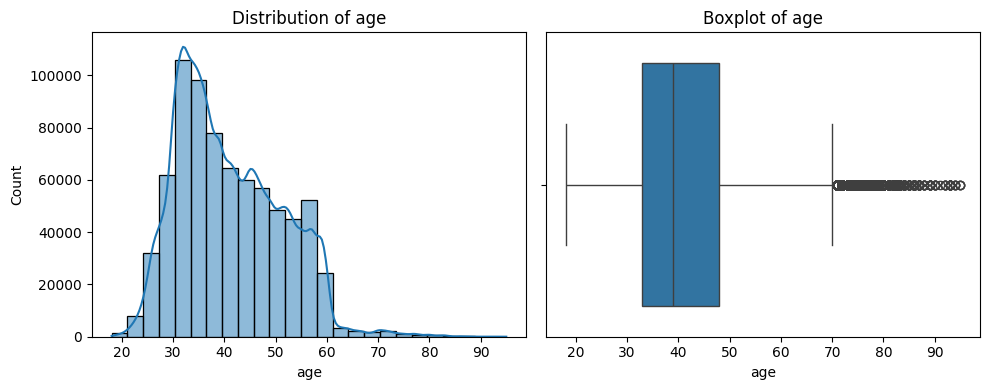

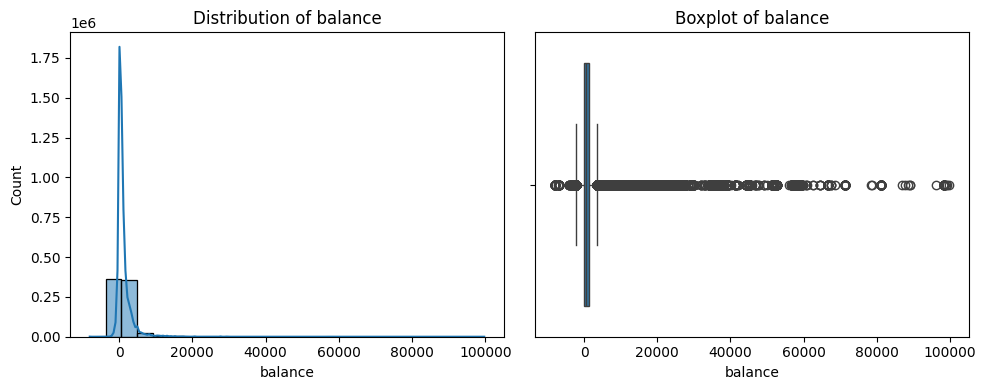

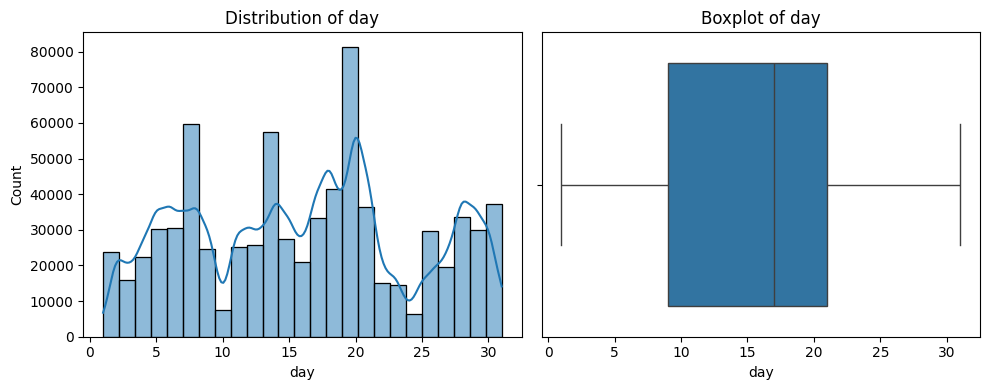

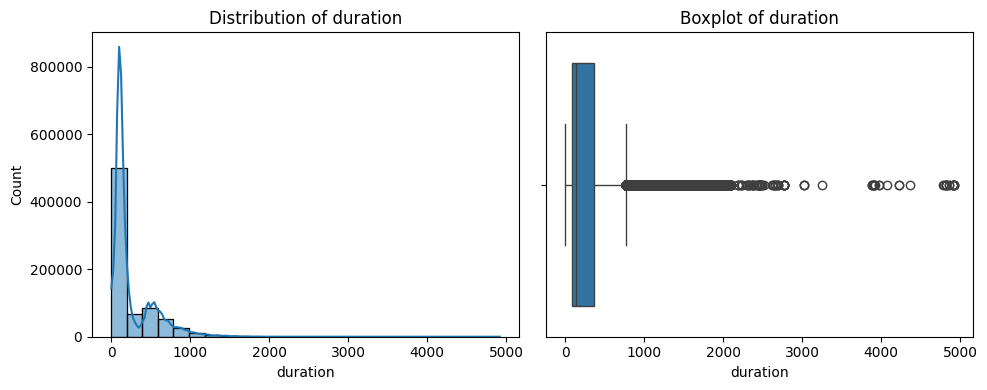

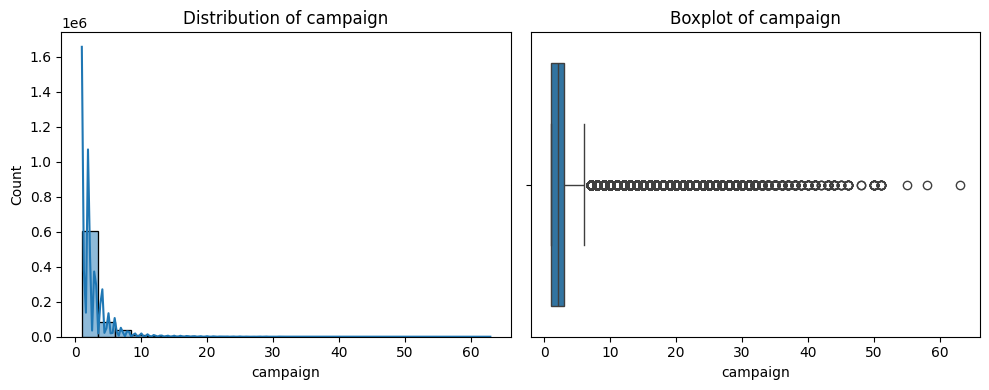

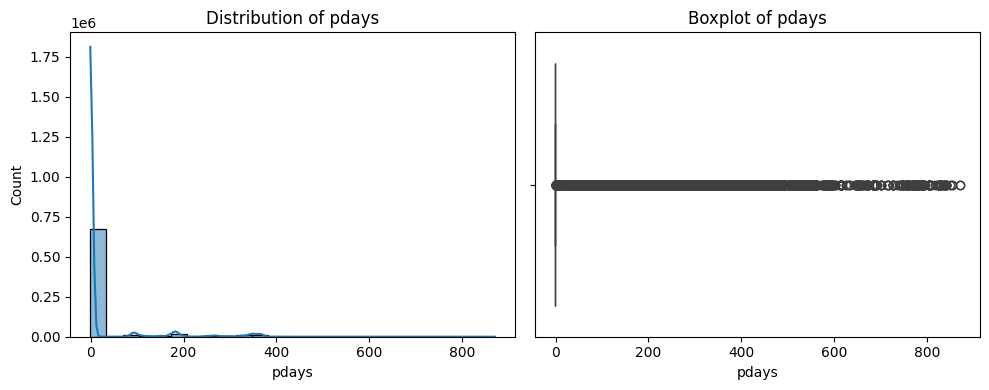

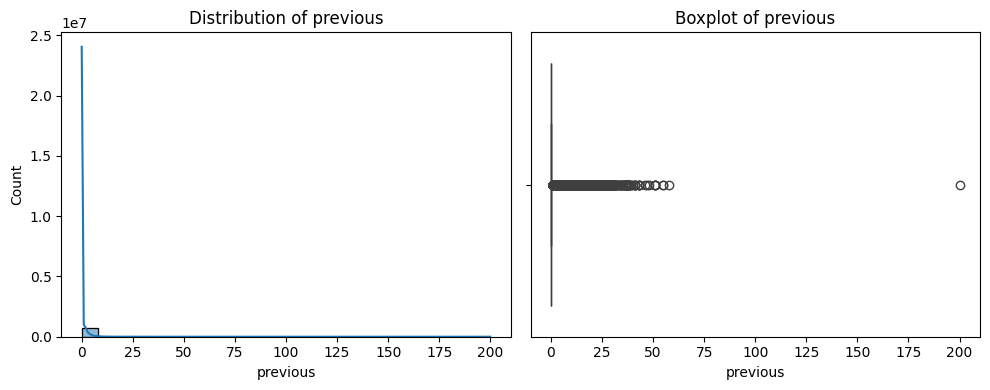

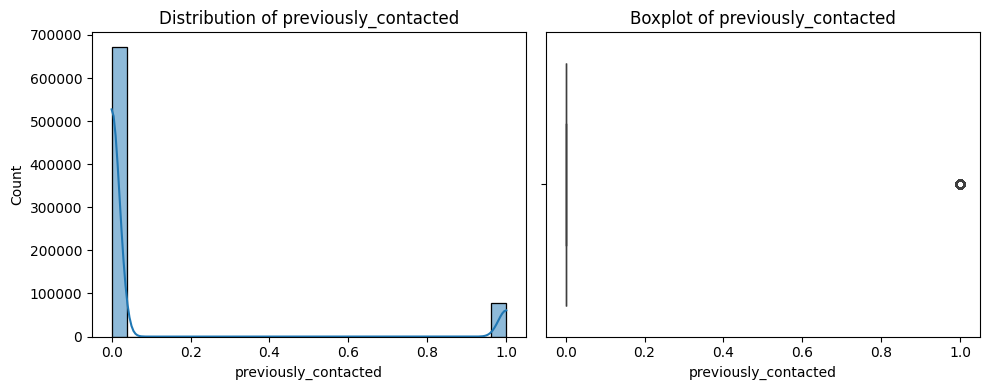

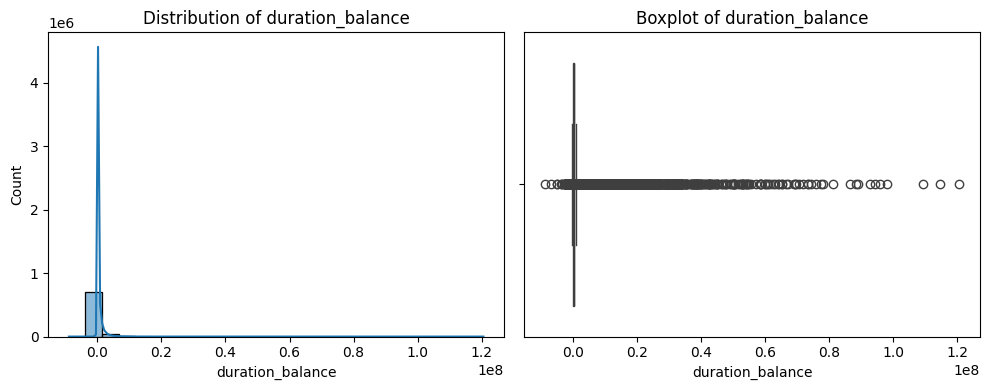

In [12]:
for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram
    sns.histplot(train_transformed[col], kde=True, bins=25, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')

    # Boxplot
    sns.boxplot(x=train_transformed[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()


In [13]:
# let's double check skewness of numerical features, that we can also empirically see from the histograms and boxplots
skewness = train_transformed[numerical_features].skew() # positive skewness means right-skewed, negative skewness means left-skewed
print("Skewness of numerical features:")
print(skewness.sort_values(ascending=False))

Skewness of numerical features:
duration_balance        20.506033
previous                13.749885
balance                 12.304123
campaign                 4.810437
pdays                    3.625049
previously_contacted     2.604719
duration                 2.048776
age                      0.586137
day                      0.054014
dtype: float64


Some of the numerical features are highly skewed, such as:
- previous: it makes sense, since most clients were not contacted in previous campaigns, so the distribution is skewed towards zero.
- balance: it is skewed because some clients may have very high balances, while most have little money.
- campaign: it is skewed because most clients may have been contacted only once (which is the minimum value since it also includes last contact), while a few clients may have been contacted many times.
- pdays: it is skewed because most clients were not contacted in previous campaigns (pdays = -1), while a few clients may have been contacted recently (pdays close to zero) or a long time ago (pdays with high positive values).
- duration: it is skewed because most calls may have been short, while a few calls may have been very long.

Since balance can have negative values, we cannot apply a log transformation to it, but we can apply a cube-root transformation, which can handle negative values and also reduce skewness.

In [14]:
def transform_and_plot_skewed(train_df, test_df, cols, plot=True):
    for col in cols:
        #cube-root transformation for balance, since it can have negative values
        if col == 'balance':  # we apply cube-root transformation only to balance, since it is the most skewed feature and it can have negative values
            train_df[col] = np.cbrt(train_df[col])
            test_df[col] = np.cbrt(test_df[col])
        elif col == 'pdays':
            train_df[col] = np.where(train_df[col] > -1, np.log1p(train_df[col]), 0) # we use np.log1p to handle the case when pdays = 0, since log(0) is undefined. For pdays = -1, we set the log-transformed value to 0 (or any constant), since it indicates that the client was not previously contacted.
            test_df[col] = np.where(test_df[col] > -1, np.log1p(test_df[col]), 0) # we use np.log1p to handle the case when
        else:
            train_df[col] = np.log1p(train_df[col]) # log1p is used to handle the case when the feature can have zero values, since log(0) is undefined
            test_df[col] = np.log1p(test_df[col])

        if plot:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            sns.histplot(train_df[col], kde=True, bins=25, ax=axes[0])
            axes[0].set_title(f'Distribution of transformed {col}')
            sns.boxplot(x=train_df[col], ax=axes[1])
            axes[1].set_title(f'Boxplot of transformed {col}')
            plt.tight_layout()
            plt.show()

skewed_features = skewness[skewness.abs() > 1].index.tolist()

transform_and_plot_skewed(train_transformed, test_transformed, skewed_features, plot=False)

/usr/lib/python3/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/lib/python3/dist-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
skewness_transformed = train_transformed[numerical_features].skew() # positive skewness means right-skewed, negative skewness means left-skewed
print("Skewness of numerical features (after transformation):")
print(skewness_transformed.sort_values(ascending=False))

Skewness of numerical features (after transformation):
previous                3.619914
pdays                   2.664730
previously_contacted    2.604719
campaign                1.323181
age                     0.586137
day                     0.054014
balance                -0.317423
duration               -0.356506
duration_balance       -1.360047
dtype: float64


## 7. Categorical variables

In [26]:
# categorical features
categorical_cols = train_transformed.select_dtypes(include=['object']).columns

print("Target variable distribution:")
print(train['y'].value_counts(normalize=True) * 100)

Target variable distribution:
y
0    87.934933
1    12.065067
Name: proportion, dtype: float64


### Target Rate by Categorical Feature

The code below computes, for each categorical feature, the percentage of clients who subscribed to a term deposit (`y=1`) broken down by each category value.

This is useful because it reveals which category values are associated with higher or lower subscription rates, helping us identify the most predictive categorical features and potential candidates for target encoding.

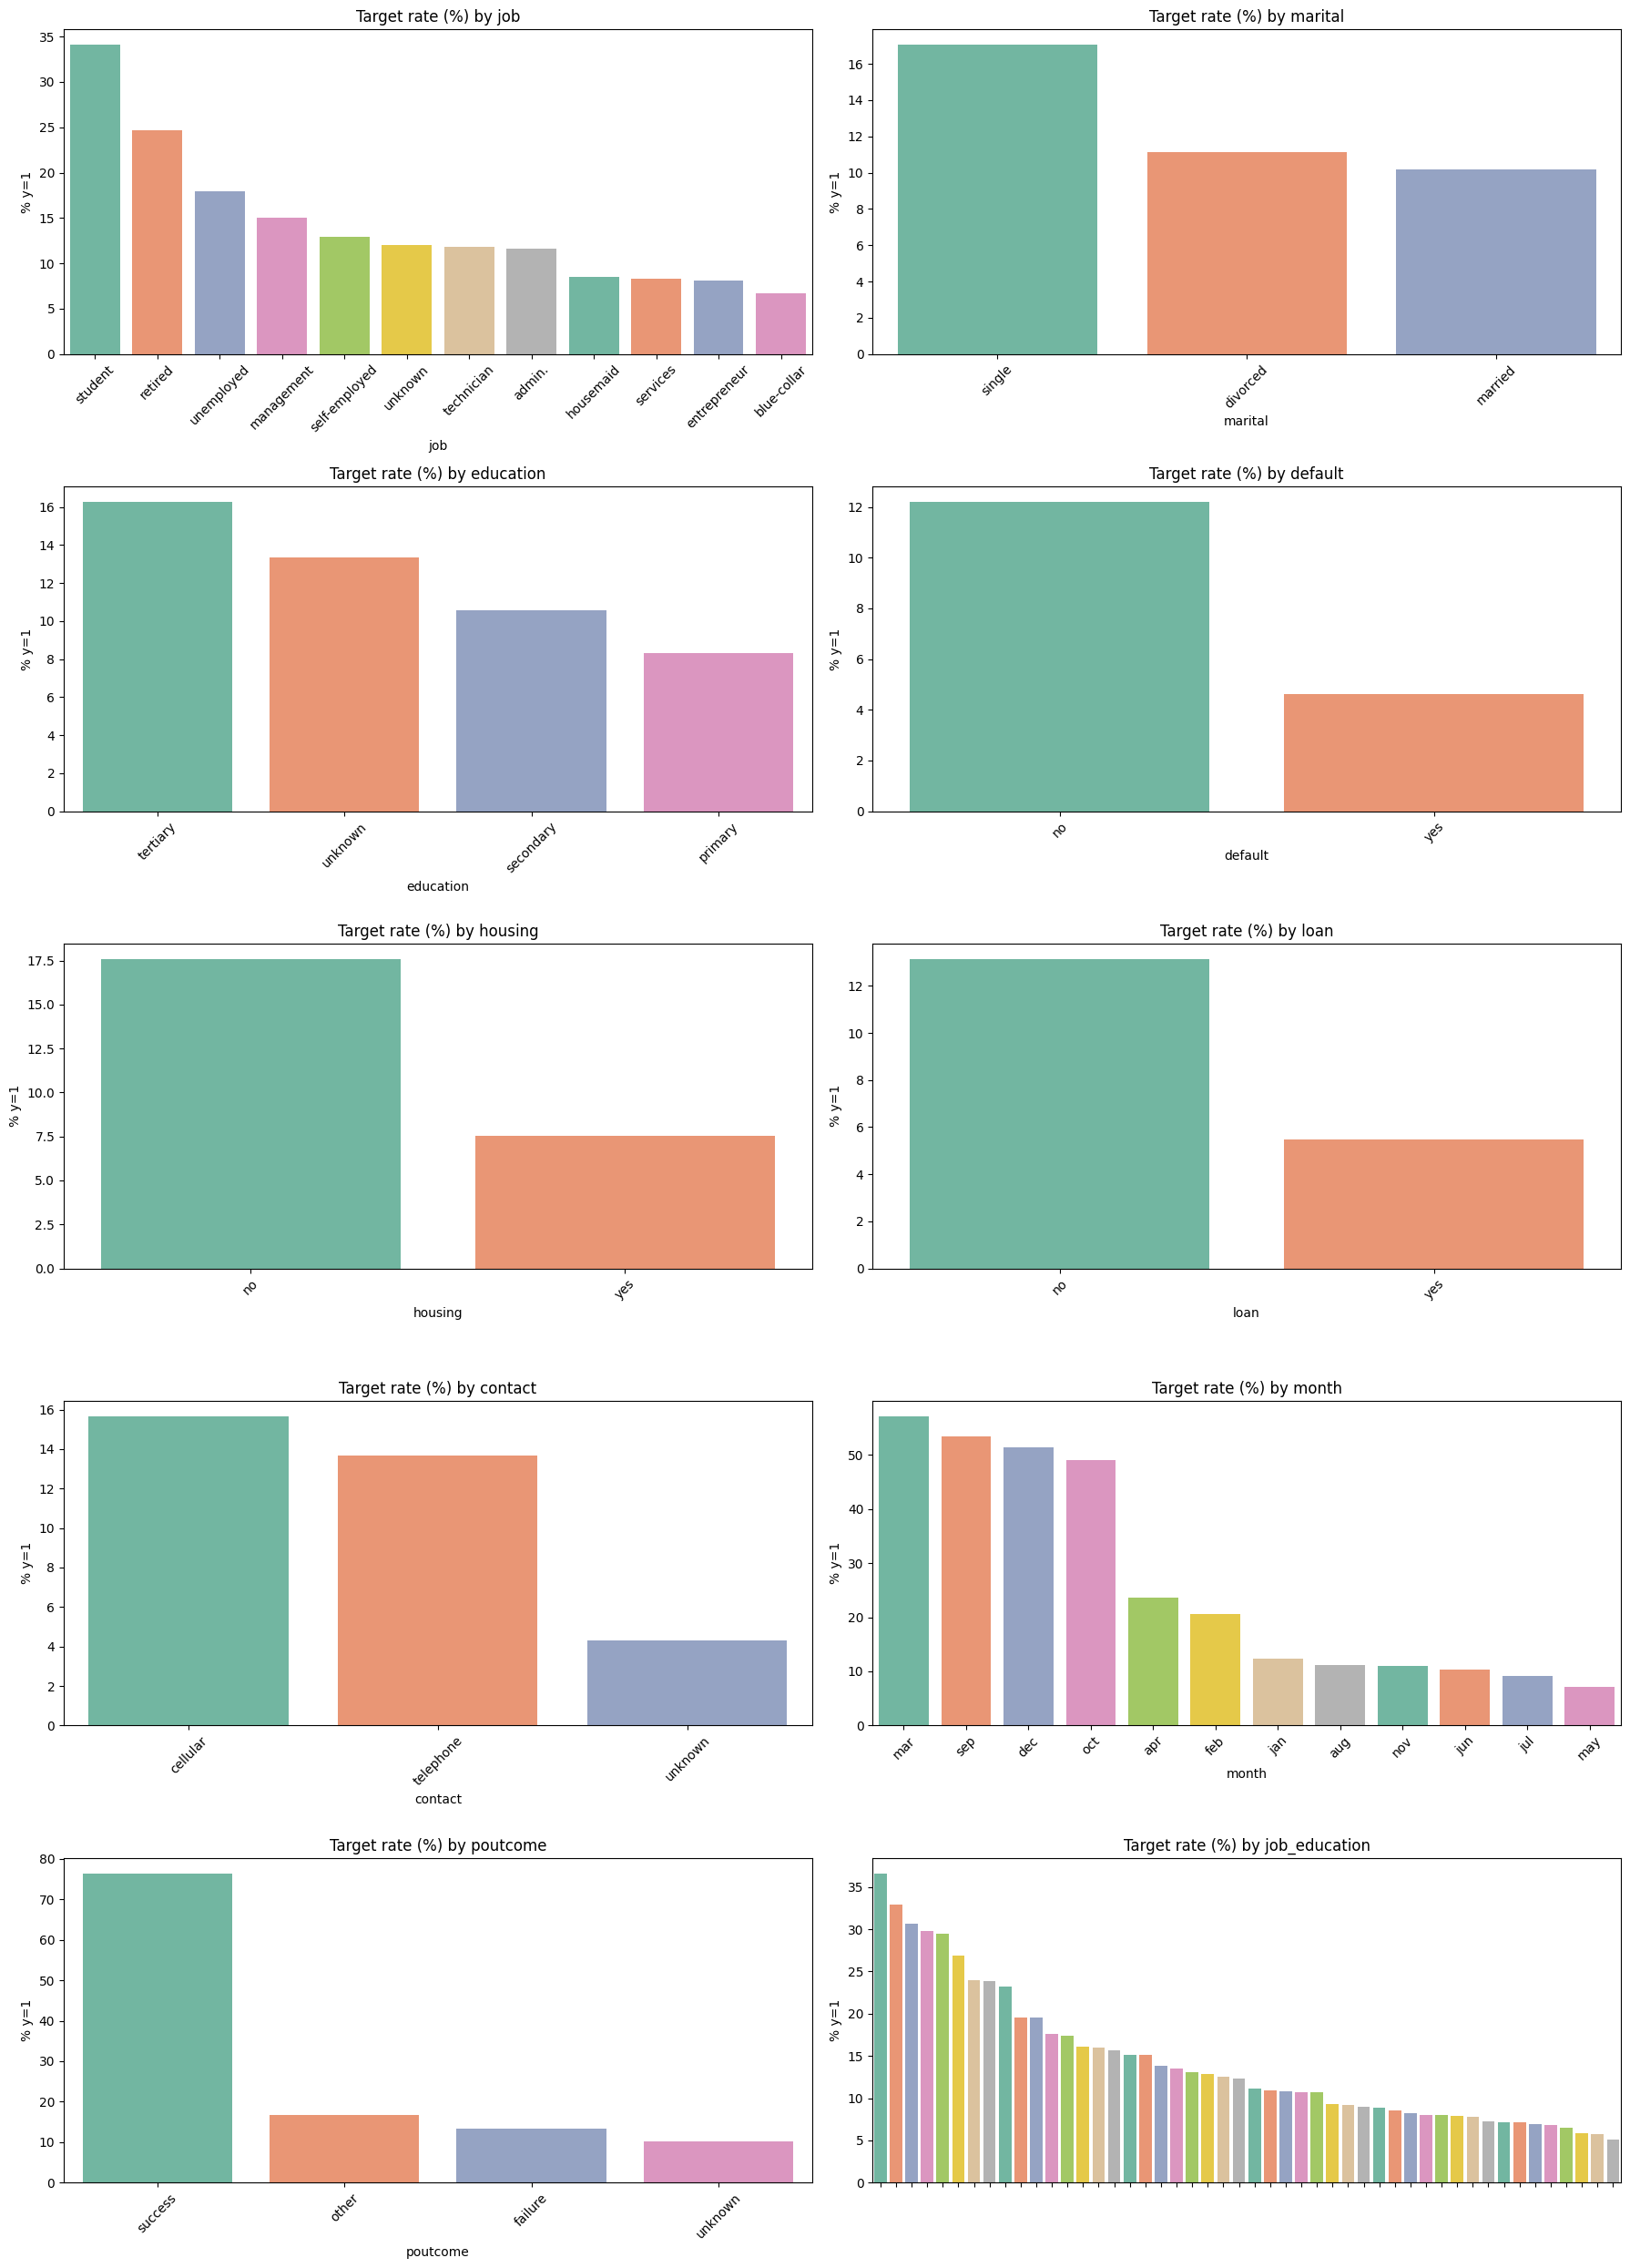

In [34]:
n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    percentages = train_transformed.groupby(col)['y'].mean() * 100
    percentages = percentages.sort_values(ascending=False)
    sns.barplot(x=percentages.index, y=percentages.values, ax=axes[i], hue=percentages.index, palette="Set2", legend=False)
    axes[i].set_title(f'Target rate (%) by {col}')
    axes[i].set_ylabel('% y=1')
    if col == 'job_education': # otherwise the x-axis labels would be too crowded for the job_education feature, since it has many unique values
        axes[i].set_xticklabels([])
        axes[i].set_xlabel('')
    else:
        axes[i].set_xlabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Based on this plot, I would consider important categorical features for the model to be:
- poutcome: if the outcome of the previous campaign was a success, the target rate is much higher
- month: correlation between the label-encoded month and the target variable would be low because the target rate does not increase or decrease monotonically with the month, but there are some months with higher target rates and some with definitely lower target rates
- job and education (and job_education)

### 8. Encoding categorical variables

In [18]:
# Encoding categorical variables

def encode_categorical(train_df, test_df, method="onehot"):

    cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()

    if method == "label":
        train_encoded = pd.DataFrame(index=train_df.index)
        test_encoded = pd.DataFrame(index=test_df.index)

        for col in cat_cols:
            le = LabelEncoder()
            le.fit(pd.concat([train_df[col], test_df[col]], axis=0))
            train_encoded[col] = le.transform(train_df[col])
            test_encoded[col] = le.transform(test_df[col])

        return train_encoded, test_encoded

    elif method == "onehot":
        train_cats = train_df[cat_cols].copy()
        test_cats = test_df[cat_cols].copy()

        combined = pd.concat([train_cats, test_cats], axis=0)
        combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=False)

        train_encoded = combined_encoded.iloc[: len(train_df), :].copy()
        test_encoded = combined_encoded.iloc[len(train_df) :, :].copy()

        return train_encoded, test_encoded


    elif method == "frequency":
        train_encoded = pd.DataFrame(index=train_df.index)
        test_encoded = pd.DataFrame(index=test_df.index)

        for col in cat_cols:
            freq = pd.concat([train_df[col], test_df[col]], axis=0).value_counts()
            train_encoded[col] = train_df[col].map(freq)
            test_encoded[col] = test_df[col].map(freq)

        return train_encoded, test_encoded

    elif method == "target":
        train_encoded = pd.DataFrame(index=train_df.index)
        test_encoded = pd.DataFrame(index=test_df.index)

        for col in cat_cols:
            target_mean = train_df.groupby(col)['y'].mean()
            train_encoded[col] = train_df[col].map(target_mean)
            test_encoded[col] = test_df[col].map(target_mean)

        return train_encoded, test_encoded

    else:
        raise ValueError("Invalid encoding method. Choose 'label' or 'onehot'.")

In [35]:
def build_encoded_datasets(train_df, test_df, numerical_features, method="label"):
    # encode categoricals (possibly including y) from train_df / test_df
    cat_train_encoded, cat_test_encoded = encode_categorical(
        train_df, test_df, method=method
    )

    y_encoded = train_df["y"]

    # Build final encoded train set: numerical (transformed) + encoded categoricals + target y
    train_encoded = pd.concat(
        [
            train_df[numerical_features],  # numeric only
            cat_train_encoded,             # encoded categoricals (no y)
        ],
        axis=1,
    )
    train_encoded["y"] = y_encoded.values  # single numeric target column

    # Build final encoded test set: numerical (transformed) + encoded categoricals (no y)
    test_encoded = pd.concat(
        [
            test_df[numerical_features],
            cat_test_encoded,
        ],
        axis=1,
    )

    # sanity check: no duplicate columns
    assert not train_encoded.columns.duplicated().any()

    print("Encoded train features:")
    print(train_encoded.columns.tolist())
    print("Number of features:", len(train_encoded.columns))

    return train_encoded, test_encoded

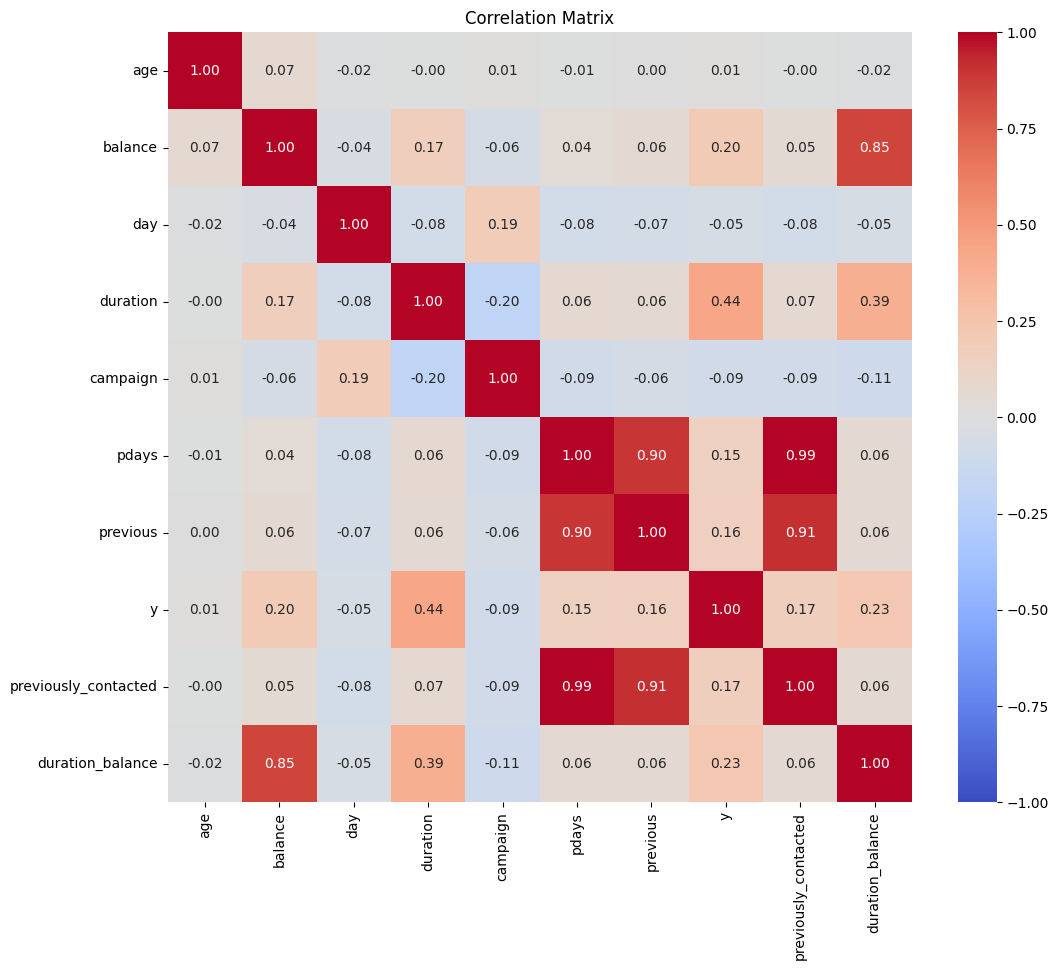

In [ ]:
# correlation matrix AFTER feature engineering

numeric_cols = train_transformed.select_dtypes(include=[np.number]).columns
numerical_features = [col for col in numeric_cols if col != 'y']

plt.figure(figsize=(12, 10))
sns.heatmap(train_transformed[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# ML MODELS

### 9. Random Forest as a baseline model

Encoded train features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'duration_balance', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job_education', 'y']
Number of features: 20
AUC ROC score:  0.9607547461284445


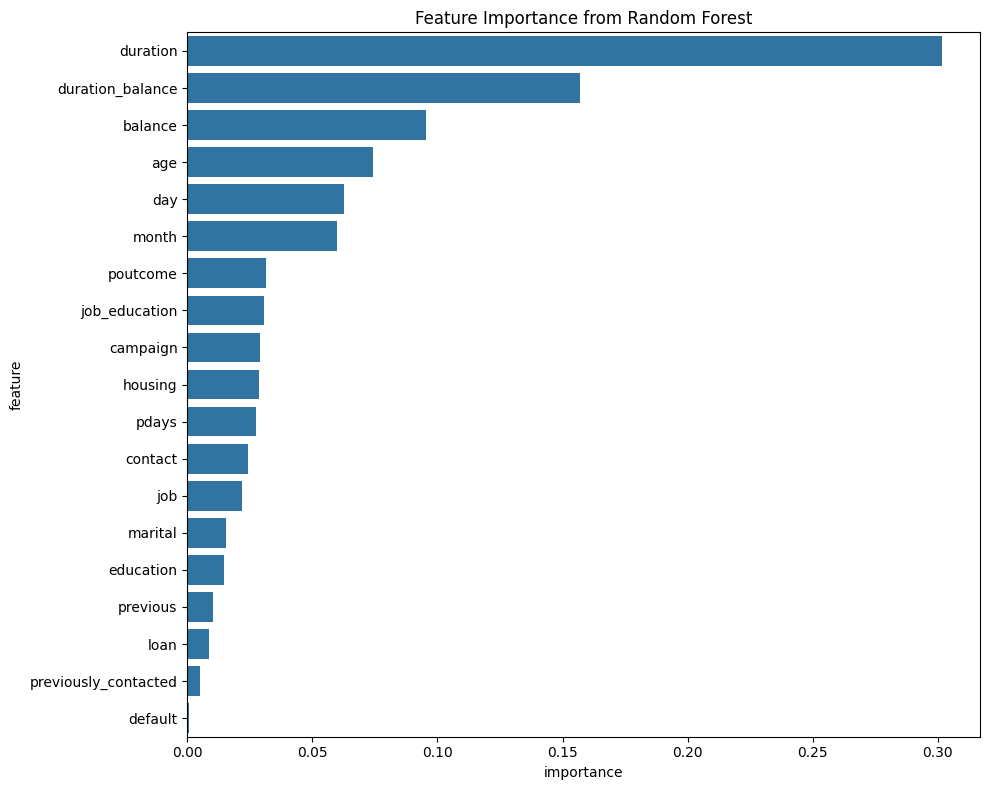

In [21]:
# test a simple random forest to then see feature importanfce

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

train_encoded, test_encoded = build_encoded_datasets(
    train_transformed, test_transformed, numerical_features, method="label"
)

X = train_encoded.drop("y", axis=1)
y = train_encoded["y"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
print("AUC ROC score: ", roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1]))

#feature importance plotting
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})

#plot
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=feature_importance_df.sort_values(by="importance", ascending=False))
plt.title("Feature Importance from Random Forest")
plt.tight_layout()
plt.show()


### 10. XGBoost with stratified 10-fold CV

In [ ]:
# XGBoost with stratified 10-fold CV

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

# rebuild encoded datasets with frequency encoding for tree-based models
train_encoded, test_encoded = build_encoded_datasets(
    train_transformed, test_transformed, numerical_features, method="frequency"
)

X_train = train_encoded.drop('y', axis=1)
y_train = train_encoded['y']

# Best parameters identified from parameter search:
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "booster": "gbtree",
    "max_depth": 7,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "reg_alpha": 0.01,
    "reg_lambda": 1,
    "random_state": 42,
    "n_estimators": 10000,
    "early_stopping_rounds": 100,
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(X_train))
xgb_test_fold_predictions = np.zeros((skf.n_splits, test_encoded.shape[0]))
cv_scores = []

print("Training XGBoost with 10-fold stratified cross-validation...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    model = XGBClassifier(**xgb_params)
    model.set_params(verbosity=1)  # Set verbosity to 1 for fold-level training output

    model.fit(
        X_fold_train,
        y_fold_train,
        eval_set=[(X_fold_train, y_fold_train), (X_fold_val, y_fold_val)],  # track AUC on train/val
        verbose=0,
    )

    val_pred = model.predict_proba(X_fold_val)[:, 1]
    oof_predictions[val_idx] = val_pred  # out-of-fold predictions

    # predict on the full test set for this fold
    test_fold_pred = model.predict_proba(test_encoded)[:, 1]
    xgb_test_fold_predictions[fold, :] = test_fold_pred

    fold_score = roc_auc_score(y_fold_val, val_pred)
    cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

# average test predictions across folds (10 versions of Model 1)
xgb_test_pred = xgb_test_fold_predictions.mean(axis=0)

xgb_score = roc_auc_score(y_train, oof_predictions)  # overall OOF score

print("\n" + "=" * 30)
print("XGBoost Results:")
print("CV Scores:", [f"{score:.6f}" for score in cv_scores])
print(f"Mean CV Score: {np.mean(cv_scores):.6f} ± {np.std(cv_scores):.6f}")
print(f"Overall OOF Score: {xgb_score:.6f}")
print("=" * 30)

# store for later use in a meta-learner / stacking
xgb_oof = oof_predictions.copy()

print("\nXGBoost training completed!")
print(f"Best ROC AUC Score: {xgb_score:.6f}")

Encoded train features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'duration_balance', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job_education', 'y']
Number of features: 20
Training XGBoost with 10-fold stratified cross-validation...

Fold 1/10
Fold 1 ROC AUC: 0.969190

Fold 2/10
Fold 2 ROC AUC: 0.967797

Fold 3/10
Fold 3 ROC AUC: 0.967018

Fold 4/10
Fold 4 ROC AUC: 0.967609

Fold 5/10
Fold 5 ROC AUC: 0.967055

Fold 6/10
Fold 6 ROC AUC: 0.967810

Fold 7/10
Fold 7 ROC AUC: 0.968558

Fold 8/10
Fold 8 ROC AUC: 0.967945

Fold 9/10
Fold 9 ROC AUC: 0.968238

Fold 10/10
Fold 10 ROC AUC: 0.967614

XGBoost Results:
CV Scores: ['0.969190', '0.967797', '0.967018', '0.967609', '0.967055', '0.967810', '0.968558', '0.967945', '0.968238', '0.967614']
Mean CV Score: 0.967883 ± 0.000624
Overall OOF Score: 0.967881

XGBoost training completed!
Best ROC AUC Score: 0.967881


### 11. CatBoost with stratified 10-fold CV

In [ ]:
# CatBoost with Stratified 10-Fold CV on RAW (non-encoded) categorical features and test-time ensembling

from catboost import CatBoostClassifier
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

print("=" * 50)
print("MODEL: CatBoost Classifier (Stratified 10-Fold CV, all features as raw categoricals)")
print("=" * 50)

# Use train_transformed directly (it already contains your engineered features)
# target column is 'y'
X_cb = train_transformed.drop("y", axis=1)
y_cb = train_transformed["y"].values

# Build corresponding test set
X_cb_test = test_transformed.copy()

# Convert all columns to string type for CatBoost to treat them as categorical
for col in X_cb.columns:
    X_cb[col] = X_cb[col].astype(str)
    X_cb_test[col] = X_cb_test[col].astype(str)

# All features are now strings, so all are categorical for CatBoost
cat_features = list(range(X_cb.shape[1]))  # Pass all column indices

print("Categorical features passed to CatBoost (all features):", X_cb.columns.tolist())

# Best parameters identified from parameter search:
# learning_rate: 0.05, depth: 7

cat_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "learning_rate": 0.05,
    "depth": 7,
    "n_estimators": 10000,  # Max iterations, early stopping will find optimal
    "random_seed": 42,
    "od_wait": 100,   # early stopping rounds
    "task_type": "GPU",
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cat_oof_predictions = np.zeros(len(X_cb))
cat_test_fold_predictions = np.zeros((skf.n_splits, X_cb_test.shape[0]))
cat_cv_scores = []

print("Training CatBoost with 10-fold stratified cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cb, y_cb)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    X_fold_train = X_cb.iloc[train_idx]
    X_fold_val = X_cb.iloc[val_idx]
    y_fold_train = y_cb[train_idx]
    y_fold_val = y_cb[val_idx]

    model = CatBoostClassifier(**cat_params)

    model.fit(
        X_fold_train,
        y_fold_train,
        eval_set=(X_fold_val, y_fold_val),
        cat_features=cat_features,
        early_stopping_rounds=cat_params["od_wait"],
        use_best_model=True,
        verbose = 0
    )

    val_pred = model.predict_proba(X_fold_val)[:, 1]
    cat_oof_predictions[val_idx] = val_pred

    # predict on the full test set for this fold
    test_fold_pred = model.predict_proba(X_cb_test)[:, 1]
    cat_test_fold_predictions[fold, :] = test_fold_pred

    fold_score = roc_auc_score(y_fold_val, val_pred)
    cat_cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

# average test predictions across folds (10 versions of Model 2)
cat_test_pred = cat_test_fold_predictions.mean(axis=0)

cat_score = roc_auc_score(y_cb, cat_oof_predictions)

print("\n" + "=" * 30)
print("CatBoost Results (Best Parameters):")
print("CV Scores:", [f"{score:.6f}" for score in cat_cv_scores])
print(f"Mean CV Score: {np.mean(cat_cv_scores):.6f} ± {np.std(cat_cv_scores):.6f}")
print(f"Overall OOF Score: {cat_score:.6f}")
print("=" * 30)

# store for later use in a meta-learner / stacking
cat_oof = cat_oof_predictions.copy()

print("\nCatBoost training completed!")
print(f"Final ROC AUC Score: {cat_score:.6f}")

MODEL: CatBoost Classifier (Stratified 10-Fold CV, all features as raw categoricals)
Categorical features passed to CatBoost (all features): ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'previously_contacted', 'job_education', 'duration_balance']
Training CatBoost with 10-fold stratified cross-validation...

Fold 1/10


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1 ROC AUC: 0.975396

Fold 2/10


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2 ROC AUC: 0.973582

Fold 3/10


...

Fold 8 ROC AUC: 0.973728

Fold 9/10


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 9 ROC AUC: 0.973339

Fold 10/10


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 10 ROC AUC: 0.973107

CatBoost Results (Best Parameters):
CV Scores: ['0.975396', '0.973582', '0.973069', '0.973304', '0.972192', '0.972672', '0.974183', '0.973728', '0.973339', '0.973107']
Mean CV Score: 0.973457 ± 0.000831
Overall OOF Score: 0.973454

CatBoost training completed!
Final ROC AUC Score: 0.973454


### 12. LightGBM with stratified 10-fold CV

In [ ]:
# LightGBM with Stratified 10-Fold cross-validation (OOF predictions and test-time ensembling)

from lightgbm import LGBMClassifier
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings("ignore")

train_encoded, test_encoded = build_encoded_datasets(
    train_transformed, test_transformed, numerical_features, method="frequency"
)

X_train = train_encoded.drop('y', axis=1)
y_train = train_encoded['y']

print("=" * 50)
print("MODEL: LightGBM Classifier (Stratified 10-Fold CV, GPU)")
print("=" * 50)

# Best parameters identified from parameter search:
lgbm_params = {
    "objective": "binary",
    "metric": "auc",
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "random_state": 42,
    "device_type": "gpu",
    "verbosity": 0
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lgbm_oof_predictions = np.zeros(len(X_train))
lgbm_test_fold_predictions = np.zeros((skf.n_splits, test_encoded.shape[0]))
lgbm_cv_scores = []

print("Training LightGBM with 10-fold stratified cross-validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    model = LGBMClassifier(**lgbm_params)

    model.fit(
        X_fold_train,
        y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        eval_metric="auc",
        callbacks=[],
    )

    val_pred = model.predict_proba(X_fold_val)[:, 1]
    lgbm_oof_predictions[val_idx] = val_pred

    # predict on the full test set for this fold
    test_fold_pred = model.predict_proba(test_encoded)[:, 1]
    lgbm_test_fold_predictions[fold, :] = test_fold_pred

    fold_score = roc_auc_score(y_fold_val, val_pred)
    lgbm_cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

# average test predictions across folds (10 versions of Model 3)
lgbm_test_pred = lgbm_test_fold_predictions.mean(axis=0)

lgbm_score = roc_auc_score(y_train, lgbm_oof_predictions)

print("\n" + "=" * 30)
print("LightGBM Results:")
print("CV Scores:", [f"{score:.6f}" for score in lgbm_cv_scores])
print(f"Mean CV Score: {np.mean(lgbm_cv_scores):.6f} ± {np.std(lgbm_cv_scores):.6f}")
print(f"Overall OOF Score: {lgbm_score:.6f}")
print("=" * 30)

# store for later use in a meta-learner / stacking
lgbm_oof = lgbm_oof_predictions.copy()

print("\nLightGBM training completed!")
print(f"Best ROC AUC Score: {lgbm_score:.6f}")

Encoded train features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'previously_contacted', 'duration_balance', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job_education', 'y']
Number of features: 20
MODEL: LightGBM Classifier (Stratified 10-Fold CV, GPU)
Training LightGBM with 10-fold stratified cross-validation...

Fold 1/10
Fold 1 ROC AUC: 0.969930

Fold 2/10
Fold 2 ROC AUC: 0.968758

Fold 3/10
Fold 3 ROC AUC: 0.967908

Fold 4/10
Fold 4 ROC AUC: 0.968848

Fold 5/10
Fold 5 ROC AUC: 0.967502

Fold 6/10
Fold 6 ROC AUC: 0.968806

Fold 7/10
Fold 7 ROC AUC: 0.969613

Fold 8/10
Fold 8 ROC AUC: 0.969131

Fold 9/10
Fold 9 ROC AUC: 0.969097

Fold 10/10
Fold 10 ROC AUC: 0.968411

LightGBM Results:
CV Scores: ['0.969930', '0.968758', '0.967908', '0.968848', '0.967502', '0.968806', '0.969613', '0.969131', '0.969097', '0.968411']
Mean CV Score: 0.968800 ± 0.000691
Overall OOF Score: 0.968799

LightGBM training completed!

### 13. Stacking with Logistic Regression as meta-model

In [ ]:
# Meta-learner (stacking) using OOF predictions from XGBoost, CatBoost, LightGBM

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Stack base model OOF predictions as features
# Make sure xgb_oof, cat_oof, lgbm_oof exist from previous cells
Z = np.column_stack([xgb_oof, cat_oof, lgbm_oof])
print("Stacked feature matrix shape (n_samples, n_models):", Z.shape)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_oof_predictions = np.zeros(len(y_train))
meta_cv_scores = []

print("Training meta-learner (Logistic Regression) with 5-fold stratified CV...")

for fold, (train_idx, val_idx) in enumerate(skf.split(Z, y_train)):
    print(f"\nFold {fold + 1}/{skf.n_splits}")

    Z_fold_train = Z[train_idx]
    Z_fold_val = Z[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    meta_model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=42,
    )

    meta_model.fit(Z_fold_train, y_fold_train)

    val_pred = meta_model.predict_proba(Z_fold_val)[:, 1]
    meta_oof_predictions[val_idx] = val_pred

    fold_score = roc_auc_score(y_fold_val, val_pred)
    meta_cv_scores.append(fold_score)
    print(f"Fold {fold + 1} ROC AUC: {fold_score:.6f}")

meta_score = roc_auc_score(y_train, meta_oof_predictions)

print("\n" + "=" * 30)
print("Meta-learner (Stacking) Results:")
print("CV Scores:", [f"{score:.6f}" for score in meta_cv_scores])
print(f"Mean CV Score: {np.mean(meta_cv_scores):.6f} ± {np.std(meta_cv_scores):.6f}")
print(f"Overall OOF Score: {meta_score:.6f}")
print("=" * 30)

# Confusion matrix on training (using OOF predictions, threshold 0.5)
y_train_meta_pred = (meta_oof_predictions >= 0.5).astype(int) # convert probabilities to binary predictions using 0.5 threshold
cm_meta = confusion_matrix(y_train, y_train_meta_pred)
print("\nConfusion matrix (meta-learner, OOF predictions):")
print(cm_meta)

print("\nStacking meta-learner training completed!")
print(f"Best ROC AUC Score (meta-learner): {meta_score:.6f}")

# Train final meta-learner on the full training set
meta_model_full = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)
meta_model_full.fit(Z, y_train)

# Build stacked features for the test set using the averaged
# predictions from each base model (10 versions per model)
Z_test = np.column_stack([xgb_test_pred, cat_test_pred, lgbm_test_pred])
print("Stacked TEST feature matrix shape (n_samples, n_models):", Z_test.shape)

# Final test predictions from the meta-learner
test_pred_meta = meta_model_full.predict_proba(Z_test)[:, 1]

Stacked feature matrix shape (n_samples, n_models): (750000, 3)
Training meta-learner (Logistic Regression) with 5-fold stratified CV...

Fold 1/5
Fold 1 ROC AUC: 0.975215

Fold 2/5
Fold 2 ROC AUC: 0.974179

Fold 3/5
Fold 3 ROC AUC: 0.973651

Fold 4/5
Fold 4 ROC AUC: 0.974928

Fold 5/5
Fold 5 ROC AUC: 0.974328

Meta-learner (Stacking) Results:
CV Scores: ['0.975215', '0.974179', '0.973651', '0.974928', '0.974328']
Mean CV Score: 0.974460 ± 0.000555
Overall OOF Score: 0.974395

Confusion matrix (meta-learner, OOF predictions):
[[644125  15387]
 [ 26542  63946]]

Stacking meta-learner training completed!
Best ROC AUC Score (meta-learner): 0.974395
Stacked TEST feature matrix shape (n_samples, n_models): (250000, 3)


### 14. Submission file

In [28]:
# prepare the submission using meta-learner predictions on the test set
sub = submission.copy()
sub['y'] = test_pred_meta
sub.to_csv('submission.csv', index=False)
sub.head()

,id,y
0,750000,0.015761
1,750001,0.043075
2,750002,0.015131
3,750003,0.015113
4,750004,0.019087


### SCOREBOARD
The score I obtained is 0.97478, which placed me in the top 14% of the leaderboard.